In [2]:
#自动重载外部文件的更新
%load_ext autoreload
%autoreload 2

# 添加项目路径至path
import os
import sys
currentPath = os.path.join(os.getcwd(),"machinelearningIntro","机器学习实践/聚类")
sys.path.append(currentPath)

# 要求
配对交易策略聚类分析(sp500data.xlsx) (行是日期，列是股票名称）
1.删除掉所有空缺值占比超过30%的股票
2.使用k-means, k-medoids, dbscan, agens 方法股票交易配对，并对聚类结果进行比较，分析其中的原因
提示：按月收益和月风险(月收益均值和月收益标准差）聚类

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

datadir = r"D:\PythonEx\machinelearningIntro\data\SP500Data.csv"

In [5]:
raw_df = pd.read_csv(datadir)

In [6]:
raw_df.head()

,Date,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
0,2018-01-02,58.790001,98.410004,192.490005,153.839996,64.309998,177.699997,10.98,106.089996,10.88,...,146.990005,164.300003,47.810001,29.370001,67.879997,68.070000,81.599998,124.059998,50.700001,71.769997
1,2018-01-03,58.919998,99.949997,195.820007,154.550003,65.309998,181.039993,11.55,107.050003,10.87,...,149.740005,162.520004,47.490002,29.330000,69.239998,68.900002,81.529999,124.919998,50.639999,72.099998
2,2018-01-04,58.820000,99.379997,199.250000,156.380005,64.660004,183.220001,12.12,111.000000,10.83,...,151.259995,163.399994,47.119999,29.690001,70.489998,69.360001,82.360001,124.739998,50.849998,72.529999
3,2018-01-05,58.990002,101.110001,202.320007,157.669998,66.370003,185.339996,11.88,112.180000,10.87,...,152.229996,164.490005,46.790001,29.910000,74.150002,69.230003,82.839996,125.980003,50.869999,73.360001
4,2018-01-08,58.820000,99.489998,207.800003,158.929993,66.629997,185.039993,12.28,111.389999,10.87,...,151.410004,162.300003,47.139999,30.260000,74.639999,69.480003,82.980003,126.220001,50.619999,74.239998


In [7]:
df_na_sum = raw_df.apply(lambda col:col.isna().sum(),axis=0)
df_na_sum = pd.DataFrame(df_na_sum)
df_na_sum.columns = ["空值数量"]
df_na_sum['占比'] = df_na_sum["空值数量"]/len(raw_df)
df_na_sum

,空值数量,占比
Date,0,0.0
ABT,0,0.0
ABBV,0,0.0
ABMD,0,0.0
ACN,0,0.0
...,...,...
XYL,0,0.0
YUM,0,0.0
ZBH,0,0.0
ZION,0,0.0


In [8]:
raw_df.shape

(448, 503)

# 数据清洗，删去空缺值占比较大的样本

In [9]:
df = raw_df.dropna(thresh=(1-0.3)*len(raw_df),axis=1)
df.shape

(448, 499)

In [10]:
df.describe()


,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,AMG,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
count,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,...,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000
mean,70.934196,88.078013,307.303839,167.473750,59.630804,252.270603,21.804754,147.501428,14.534888,128.423750,...,165.139486,139.475335,51.671027,29.151071,90.774487,74.549040,93.492455,120.406161,49.230245,94.787232
std,9.015754,13.480891,71.989893,14.635497,13.119012,29.001055,7.425020,21.095302,2.266254,38.573308,...,17.383970,29.251895,6.650626,3.450413,21.081242,4.926937,11.958700,9.199975,4.820335,14.395919
min,56.270000,62.980000,159.309998,133.669998,40.110001,177.699997,9.530000,103.760002,10.060000,71.800003,...,134.839996,92.010002,42.130001,18.920000,62.820000,61.380001,76.300003,97.230003,38.509998,71.510002
25%,62.620001,78.657503,260.557487,157.280006,47.037500,235.377495,15.147500,133.307499,12.847500,94.059998,...,151.705002,114.085001,45.689999,27.139999,71.664999,70.547503,83.507502,114.030001,45.107500,84.557499
50%,70.014999,88.524998,301.940002,162.880005,55.269999,254.684998,21.885000,154.949997,14.830000,113.389999,...,158.809998,132.974998,49.370001,29.075000,85.195000,75.165001,89.930000,120.645000,49.184999,90.090000
75%,78.620003,96.667498,368.095001,178.337502,71.565002,272.989990,28.437500,163.614998,16.355000,158.855000,...,178.064999,164.927498,56.715001,31.455000,109.367500,78.359999,101.462500,125.850002,53.214999,101.970001
max,88.739998,123.209999,449.750000,201.119995,83.389999,311.269989,34.389999,184.720001,18.410000,215.759995,...,199.360001,201.509995,65.820000,36.480000,139.720001,84.410004,119.209999,142.610001,58.540001,128.470001


In [11]:
df["Date"] = pd.to_datetime(df["Date"], format='%Y-%m-%d', errors='coerce')
df["Date"].describe(datetime_is_numeric=True)

C:\Users\serendipity\AppData\Local\Temp\ipykernel_12436\243649196.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Date"], format='%Y-%m-%d', errors='coerce')


count                              448
mean     2018-11-22 00:22:29.999999744
min                2018-01-02 00:00:00
25%                2018-06-12 18:00:00
50%                2018-11-19 12:00:00
75%                2019-05-03 18:00:00
max                2019-10-11 00:00:00
Name: Date, dtype: object

# 数据准备-按月的收益率

In [12]:
df

,Date,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
0,2018-01-02,58.790001,98.410004,192.490005,153.839996,64.309998,177.699997,10.980000,106.089996,10.88,...,146.990005,164.300003,47.810001,29.370001,67.879997,68.070000,81.599998,124.059998,50.700001,71.769997
1,2018-01-03,58.919998,99.949997,195.820007,154.550003,65.309998,181.039993,11.550000,107.050003,10.87,...,149.740005,162.520004,47.490002,29.330000,69.239998,68.900002,81.529999,124.919998,50.639999,72.099998
2,2018-01-04,58.820000,99.379997,199.250000,156.380005,64.660004,183.220001,12.120000,111.000000,10.83,...,151.259995,163.399994,47.119999,29.690001,70.489998,69.360001,82.360001,124.739998,50.849998,72.529999
3,2018-01-05,58.990002,101.110001,202.320007,157.669998,66.370003,185.339996,11.880000,112.180000,10.87,...,152.229996,164.490005,46.790001,29.910000,74.150002,69.230003,82.839996,125.980003,50.869999,73.360001
4,2018-01-08,58.820000,99.489998,207.800003,158.929993,66.629997,185.039993,12.280000,111.389999,10.87,...,151.410004,162.300003,47.139999,30.260000,74.639999,69.480003,82.980003,126.220001,50.619999,74.239998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,2019-10-07,81.040001,74.330002,164.429993,186.809998,55.410000,276.899994,28.930000,158.270004,15.85,...,187.589996,107.019997,64.279999,29.830000,92.629997,75.570000,113.690002,134.500000,43.439999,126.070000
444,2019-10-08,78.510002,73.529999,159.490005,182.199997,54.130001,270.829987,28.230000,154.330002,15.51,...,184.360001,102.570000,63.590000,28.309999,89.269997,73.430000,112.589996,131.220001,42.209999,125.379997
445,2019-10-09,79.500000,73.300003,159.309998,184.339996,53.430000,274.269989,28.459999,154.410004,15.54,...,186.199997,104.419998,63.919998,28.760000,90.480003,74.570000,113.330002,133.419998,42.419998,126.430000
446,2019-10-10,80.139999,74.449997,162.339996,183.830002,53.689999,274.980011,28.379999,155.949997,15.82,...,187.690002,106.059998,63.950001,28.820000,92.809998,75.430000,114.330002,134.070007,43.209999,127.410004


In [13]:
dataa = df.resample("M",on='Date').apply(lambda x: x[-1:])
dataa = dataa.drop('Date',axis= 1)
dataa

,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,AMG,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-31,62.160000,112.220001,235.000000,160.699997,74.129997,199.759995,13.740000,116.989998,11.560000,199.630005,...,160.470001,165.589996,45.639999,34.130001,73.019997,72.260002,84.589996,127.120003,54.029999,76.730003
2018-02-28,60.330002,115.830002,268.179993,161.009995,73.129997,209.130005,12.110000,114.250000,10.870000,189.360001,...,157.899994,167.500000,43.279999,30.320000,71.250000,74.580002,81.379997,116.250000,54.970001,80.860001
2018-03-31,59.919998,94.650002,290.989990,153.500000,67.459999,216.080002,10.050000,118.550003,11.370000,189.580002,...,152.190002,182.360001,45.480000,28.780001,72.239998,76.919998,85.129997,109.040001,52.730000,83.510002
2018-04-30,58.130001,96.550003,300.950012,151.199997,66.349998,221.600006,10.880000,114.449997,12.240000,164.860001,...,148.509995,186.190002,46.840000,31.450001,64.239998,72.900002,87.099998,115.169998,54.750000,83.480003
2018-05-31,61.529999,98.940002,381.140015,155.740005,70.910004,249.279999,13.730000,128.619995,12.750000,159.259995,...,151.149994,196.009995,45.520000,27.180000,68.110001,70.400002,81.330002,111.510002,54.810001,83.699997
2018-06-30,60.990002,92.650002,409.049988,163.589996,76.320000,243.809998,14.990000,135.699997,13.410000,148.669998,...,151.600006,167.339996,45.680000,24.000000,65.260002,67.379997,78.220001,111.440002,52.689999,85.190002
2018-07-31,65.540001,92.230003,354.529999,159.330002,73.419998,244.679993,18.330000,141.229996,13.360000,160.009995,...,159.419998,166.779999,46.860001,25.969999,72.070000,76.559998,79.290001,125.519997,51.700001,86.480003
2018-08-31,66.839996,95.980003,406.579987,169.070007,72.099998,263.510010,25.170000,164.029999,13.460000,146.089996,...,147.270004,148.339996,48.049999,27.860001,77.830002,75.910004,86.889999,123.629997,53.290001,90.599998
2018-09-30,73.360001,94.580002,449.750000,170.199997,83.190002,269.950012,30.889999,168.330002,14.000000,136.720001,...,140.940002,127.059998,47.209999,26.980000,80.169998,79.870003,90.910004,131.470001,50.150002,91.559998


In [14]:
datab = dataa.pct_change()
datab

,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,AMG,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-28,-0.029440,0.032169,0.141191,0.001929,-0.013490,0.046906,-0.118632,-0.023421,-0.059689,-0.051445,...,-0.016016,0.011535,-0.051709,-0.111632,-0.024240,0.032106,-0.037948,-0.085510,0.017398,0.053825
2018-03-31,-0.006796,-0.182854,0.085055,-0.046643,-0.077533,0.033233,-0.170107,0.037637,0.045998,0.001162,...,-0.036162,0.088716,0.050832,-0.050792,0.013895,0.031376,0.046080,-0.062021,-0.040750,0.032773
2018-04-30,-0.029873,0.020074,0.034228,-0.014984,-0.016454,0.025546,0.082587,-0.034585,0.076517,-0.130394,...,-0.024180,0.021002,0.029903,0.092773,-0.110742,-0.052262,0.023141,0.056218,0.038308,-0.000359
2018-05-31,0.058490,0.024754,0.266456,0.030027,0.068727,0.124910,0.261948,0.123810,0.041667,-0.033968,...,0.017777,0.052742,-0.028181,-0.135771,0.060243,-0.034294,-0.066246,-0.031779,0.001096,0.002635
2018-06-30,-0.008776,-0.063574,0.073228,0.050404,0.076294,-0.021943,0.091770,0.055046,0.051765,-0.066495,...,0.002977,-0.146268,0.003515,-0.116998,-0.041844,-0.042898,-0.038239,-0.000628,-0.038679,0.017802
2018-07-31,0.074602,-0.004533,-0.133284,-0.026041,-0.037998,0.003568,0.222815,0.040752,-0.003729,0.076276,...,0.051583,-0.003346,0.025832,0.082083,0.104352,0.136242,0.013679,0.126346,-0.018789,0.015143
2018-08-31,0.019835,0.040659,0.146814,0.061131,-0.017979,0.076958,0.373159,0.161439,0.007485,-0.086995,...,-0.076214,-0.110565,0.025395,0.072776,0.079922,-0.008490,0.095851,-0.015057,0.030754,0.047641
2018-09-30,0.097546,-0.014586,0.106178,0.006684,0.153814,0.024439,0.227255,0.026215,0.040119,-0.064139,...,-0.042982,-0.143454,-0.017482,-0.031587,0.030065,0.052167,0.046265,0.063415,-0.058923,0.010596


In [15]:
datac = datab.agg("mean")
datac.columns = ["avg_monthly_earnings_rate"]
datac

ABT     0.013006
ABBV   -0.015933
ABMD   -0.006440
ACN     0.008281
ATVI   -0.009161
          ...   
XYL     0.006522
YUM     0.015262
ZBH     0.006210
ZION   -0.006509
ZTS     0.025846
Length: 498, dtype: float64

In [16]:
datad = datab.agg("std")
datad.columns = ["std_monthly_earnings_rate"]
datad

ABT     0.049569
ABBV    0.090707
ABMD    0.133257
ACN     0.056500
ATVI    0.099154
          ...   
XYL     0.079955
YUM     0.040260
ZBH     0.077353
ZION    0.080552
ZTS     0.046337
Length: 498, dtype: float64

In [17]:
datae = pd.concat([datac,datad],axis=1)
datae.columns = ["avg_monthly_earnings_rate", "std_monthly_earnings_rate"]
datae

,avg_monthly_earnings_rate,std_monthly_earnings_rate
ABT,0.013006,0.049569
ABBV,-0.015933,0.090707
ABMD,-0.006440,0.133257
ACN,0.008281,0.056500
ATVI,-0.009161,0.099154
...,...,...
XYL,0.006522,0.079955
YUM,0.015262,0.040260
ZBH,0.006210,0.077353
ZION,-0.006509,0.080552


In [18]:
datasavedir = r"D:\PythonEx\machinelearningIntro\data\SP500Data-月收益率平均和方差.xlsx"
datae.to_excel(datasavedir)

# 数据分析-聚类

In [19]:
data7 = pd.read_excel(datasavedir)
data7.index = data7.iloc[:,0]
data7 = data7.drop("Unnamed: 0",axis=1)
data7


,avg_monthly_earnings_rate,std_monthly_earnings_rate
Unnamed: 0,,
ABT,0.013006,0.049569
ABBV,-0.015933,0.090707
ABMD,-0.006440,0.133257
ACN,0.008281,0.056500
ATVI,-0.009161,0.099154
...,...,...
XYL,0.006522,0.079955
YUM,0.015262,0.040260
ZBH,0.006210,0.077353


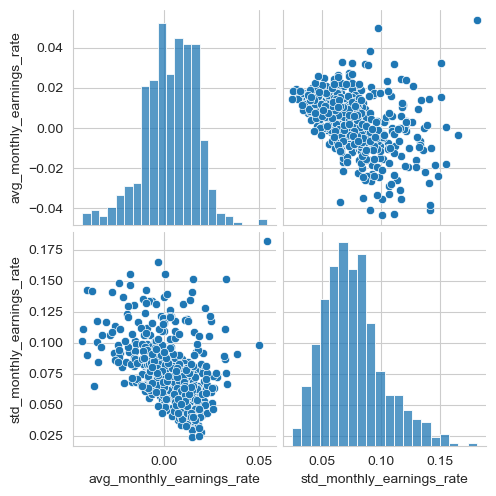

In [20]:
sns.pairplot(data7)

In [21]:
df1 = pd.DataFrame(data7.corr())
df1

,avg_monthly_earnings_rate,std_monthly_earnings_rate
avg_monthly_earnings_rate,1.000000,-0.384874
std_monthly_earnings_rate,-0.384874,1.000000


In [22]:
train_data = data7

# k-means

## sklearn的k-means

D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


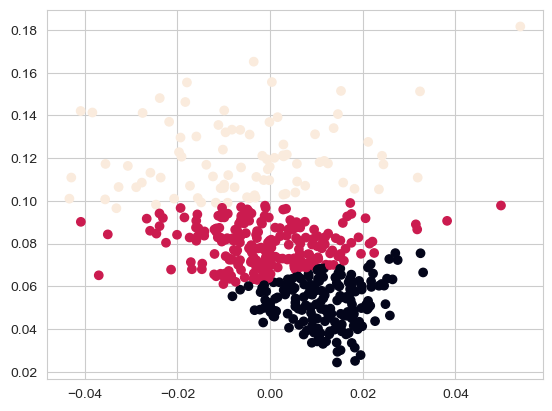

In [23]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

y_pred = KMeans(n_clusters=3, random_state=9).fit_predict(train_data)
y_pred
plt.scatter(train_data.iloc[:, 0], train_data.iloc[:, 1], c=y_pred)
plt.show()

## sklearn的k-medoids

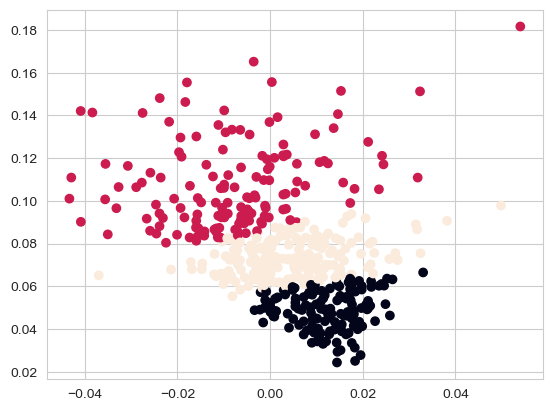

In [24]:
import matplotlib.pyplot as plt

from sklearn_extra.cluster import KMedoids

y_pred = KMedoids(n_clusters=3, random_state=9).fit_predict(train_data)
y_pred
plt.scatter(train_data.iloc[:, 0], train_data.iloc[:, 1], c=y_pred)
plt.show()

## sklearn的DBSCAN

估计的聚类个数为: 4


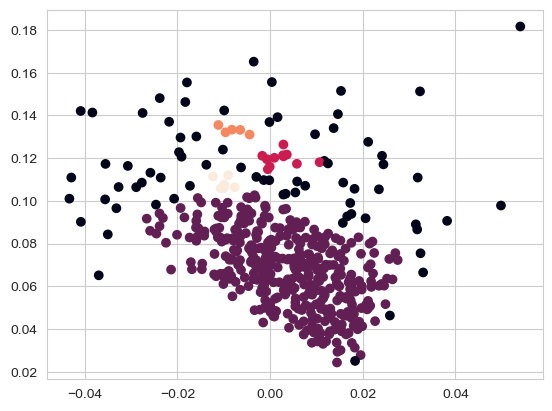

In [31]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics

# #############################################################################
# 调用密度聚类  DBSCAN
db = DBSCAN(eps=0.005, min_samples=5).fit(train_data)
# print(db.labels_)  # db.labels_为所有样本的聚类索引，没有聚类索引为-1
# print(db.core_sample_indices_) # 所有核心样本的索引
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)  # 设置一个样本个数长度的全false向量
core_samples_mask[db.core_sample_indices_] = True #将核心样本部分设置为true
labels = db.labels_

# 获取聚类个数。（聚类结果中-1表示没有聚类为离散点）
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# 模型评估
print('估计的聚类个数为: %d' % n_clusters_)

plt.scatter(train_data.iloc[:, 0], train_data.iloc[:, 1], c=labels)
plt.show()

## sklearn的AGNES

各个簇的样本数目：
0    299
2    134
1     65
dtype: int64
聚类结果：
[2 0 1 0 0 2 1 0 2 0 2 0 2 2 0 0 2 1 1 0 1 0 2 2 0 0 0 0 0 2 0 2 0 0 2 2 0
 0 0 0 0 0 0 0 2 0 1 2 0 1 1 0 1 1 2 2 2 2 0 2 2 2 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 2 0 0 0 2 0 0 0 0 1 0 0 0 0 0 0 0 2 0 1 0 2 0 0 0 0 0 0 0 2 2 0 0
 2 2 0 0 0 2 0 2 2 2 0 0 0 0 1 0 0 2 0 0 0 0 2 1 2 0 0 0 0 2 0 1 0 0 0 1 0
 0 0 1 1 1 2 0 2 0 2 2 2 0 1 0 0 0 0 2 0 0 0 0 2 0 0 0 2 2 2 2 2 2 2 0 0 2
 0 0 0 0 2 0 2 0 2 0 2 2 0 1 0 0 1 0 0 0 0 0 2 0 0 1 0 0 0 0 0 2 0 0 0 1 0
 2 0 0 2 0 0 2 1 0 2 1 0 0 0 2 0 0 0 0 0 0 2 2 0 0 0 0 2 0 0 0 0 0 2 0 0 1
 0 0 0 0 0 0 2 0 0 0 0 0 0 0 2 2 0 1 0 0 0 1 0 0 1 0 0 0 0 0 2 0 2 0 0 2 0
 0 0 0 1 1 1 0 0 2 0 0 2 2 0 2 0 2 2 0 0 0 1 1 2 2 0 0 2 0 0 0 1 0 0 0 2 0
 0 1 1 0 0 0 2 0 2 2 1 1 0 0 0 0 0 0 1 0 2 0 0 0 0 0 0 0 2 0 0 0 2 0 1 2 0
 0 2 0 0 0 2 0 2 2 2 0 2 2 0 1 0 0 1 2 0 0 0 2 2 0 0 2 2 0 0 0 0 2 0 2 2 0
 0 0 2 2 2 1 0 0 2 0 2 0 2 0 2 0 1 1 0 2 2 2 0 0 1 0 0 1 0 0 0 0 1 1 2 0 0
 2 1 0 2 1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 2 2 2

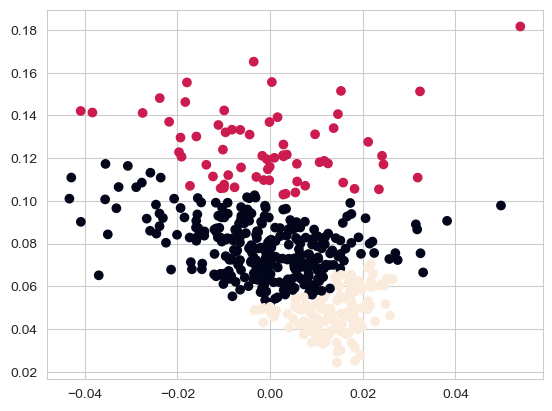

In [34]:
from sklearn.metrics import confusion_matrix
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(linkage='ward', n_clusters=3)

res = clustering.fit(train_data)

print ("各个簇的样本数目：")
print (pd.Series(clustering.labels_).value_counts())
print ("聚类结果：")
print (clustering.labels_)
plt.scatter(train_data.iloc[:, 0], train_data.iloc[:, 1], c=clustering.labels_)
plt.show()